In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from numpy.lib.stride_tricks import sliding_window_view

# Load signal
mat_path = '/Users/alicewesterberg/Desktop/wirelessproject/eitn21/Signals_task3/signal3.mat'
data = scipy.io.loadmat(mat_path)
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 58 * 10**-3


**Demodulation**

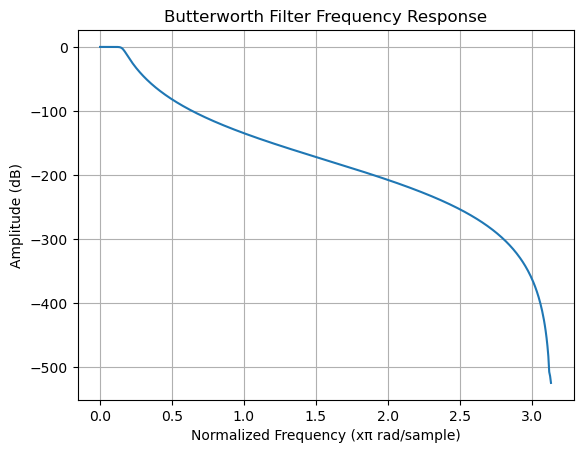

In [539]:
n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
from scipy.signal import butter, freqz, lfilter

b, a = butter(8, 0.05)
r_I_filt = lfilter(b, a, r_I)
r_Q_filt = lfilter(b, a, r_Q)

#Plot the amplitude frequency response of the filter

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency (xπ rad/sample)')
plt.ylabel('Amplitude (dB)')
plt.grid()
plt.show()

It shows how the filter attenuates different frequencies, with the x-axis representing the normalized frequency and the y-axis representing the amplitude in decibels (dB). The plot helps to visualize the characteristics of the Butterworth filter, such as its cutoff frequency and roll-off rate. High frequency components are attenuated, while low frequency components are preserved, which is characteristic of a low-pass filter. The cutoff frequency is around 0.05 times the Nyquist frequency, which corresponds to the normalized cutoff frequency used in the Butterworth filter design.

**A/D Conversion and Down Sampling**

In [540]:
D = round(fs * Tsym / Nsc)   # = round(44100 * 0.058 / 128) = 20
r_I_down = r_I_filt[::D]
r_Q_down = r_Q_filt[::D]
r_bb = r_I_down + 1j * r_Q_down
print(f'D={D}, r_bb length={len(r_bb)}, ~{len(r_bb)//(Nsc+Ncp)} OFDM symbols')


D=20, r_bb length=6353, ~42 OFDM symbols


**Synchronization and Removal of the Cyclic Prefix**

In [541]:
Tper = Nsc // 2  # = 64, pilot symbol period

wins  = sliding_window_view(r_bb, 2 * Tper)
gamma = np.sum(wins[:, :Tper] * np.conj(wins[:, Tper:]), axis=1)
phi1  = np.sum(np.abs(wins[:, :Tper])**2, axis=1)
phi2  = np.sum(np.abs(wins[:, Tper:])**2, axis=1)
mu    = np.abs(gamma) / np.sqrt(phi1 * phi2 + 1e-10)

T0 = np.argmax(mu)          # start of pilot OFDM data (after CP)
t0 = T0 - Ncp               # start of pilot CP
print(f'Pilot starts at: {t0}, OFDM data at: {T0}')

# Extract symbols from t0 (start of pilot CP)
Nofdm   = Nsc + Ncp
n_sym   = (len(r_bb) - t0) // Nofdm
ofdm_blocks = r_bb[t0 : t0 + n_sym*Nofdm].reshape(n_sym, Nofdm)
ofdm_data   = ofdm_blocks[:, Ncp:]
print(f'Total OFDM symbols: {n_sym}')


Pilot starts at: 4001, OFDM data at: 4021
Total OFDM symbols: 15


**FFT**

In [542]:
X = np.fft.fft(ofdm_data, axis=1)

**Channel estimation**

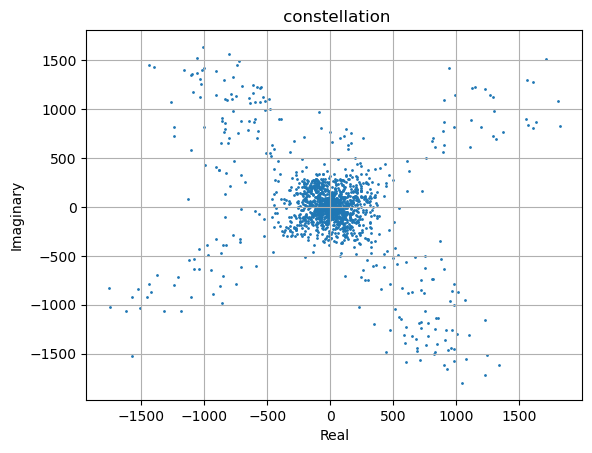

In [543]:
# H from zero-padded bits in length OFDM symbol (X[1])
# Subcarriers 15-127 carry raw zero bits → QPSK symbol is 1+j
# So H[k] = X[1, k] / (1+j) for k = 15..127
H_from_len = X[1, 15:] / (1+1j)   # shape (113,)
len_pos = np.arange(15, 128)

# Linearly extrapolate H back to even subcarriers 0-14
# to determine the sign (P) of the pilot at those positions
fit_pos = len_pos[:7]   # subcarriers 15-21
mag_p   = np.polyfit(fit_pos, np.abs(H_from_len[:7]), 1)
pha_p   = np.polyfit(fit_pos, np.unwrap(np.angle(H_from_len[:7])), 1)
extrap_pos = np.arange(0, 16, 2)   # even subcarriers 0, 2, ..., 14
H_extrap   = np.polyval(mag_p, extrap_pos) * np.exp(1j * np.polyval(pha_p, extrap_pos))

# Pilot: X[0, 0::2] at even subcarriers; raw[:8] covers subcarriers 0,2,...,14
raw   = X[0, 0::2]
P_low = np.sign(np.real(raw[:8] * np.conj(H_extrap)))
H_pilot_low = raw[:8] / (2 * P_low)

# Combine pilot-based H at 0,2,...,14 with zero-padded H at 15-127
pos_known = np.concatenate([extrap_pos, len_pos])
H_known   = np.concatenate([H_pilot_low, H_from_len])
idx       = np.argsort(pos_known)

all_pos = np.arange(Nsc)
mag_k   = np.abs(H_known[idx])
phase_k = np.unwrap(np.angle(H_known[idx]))
H_full  = (np.interp(all_pos, pos_known[idx], mag_k)
         * np.exp(1j * np.interp(all_pos, pos_known[idx], phase_k)))

plt.scatter(X[1:].real.flatten(), X[1:].imag.flatten(), s=1)
plt.title(' constellation'); plt.xlabel('Real'); plt.ylabel('Imaginary')
plt.grid(); plt.show()

**Remove pilots**

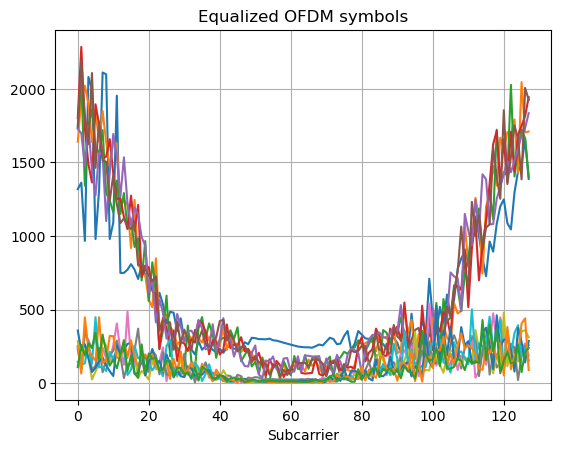

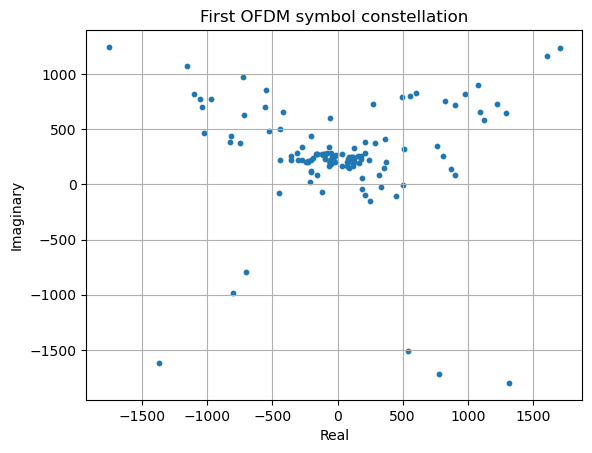

In [544]:
X_data = X[1:-1]
plt.plot(np.abs(X_data).T)
plt.title('Equalized OFDM symbols'); plt.xlabel('Subcarrier'); plt.grid(); plt.show()
plt.scatter(X_data[3].real, X_data[0].imag, s=10)
plt.title('First OFDM symbol constellation'); plt.xlabel('Real'); plt.ylabel('Imaginary')
plt.grid(); plt.show()

**Equalization**

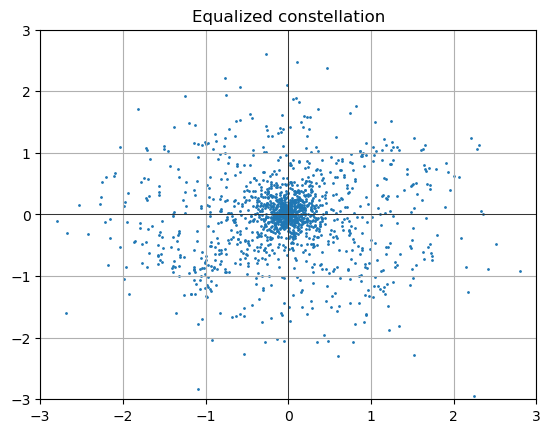

In [545]:
X_eq = X_data / (H_full + 1e-6)  # shape: (n_sym, 128) — divides each row by H estimate

plt.scatter(X_eq[1:].real.flatten(), X_eq[1:].imag.flatten(), s=1)
plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.title('Equalized constellation')
plt.grid(); plt.show()


In [546]:

bits = []
for sym in X_eq.flatten():
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')


**QPSK DEMOD**

In [547]:
bits = []
for sym in X_eq.flatten():
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')

**Decoding and ASCII**

In [548]:
from commpy.channelcoding import Trellis, viterbi_decode
trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, 0o45]]))
bits_arr = np.array(bits).astype(int)  # convert strings to ints

# First 256 bits = X_eq[0] = length OFDM symbol (128 symbols × 2 bits)
bits_len  = bits_arr[:256].astype(float)

# Remaining bits = data OFDM symbols
bits_data = bits_arr[256:].astype(float)

decoded_len = viterbi_decode(bits_len, trellis, decoding_type='hard')
l_m = int(''.join(decoded_len[:10].astype(int).astype(str)), 2)
print(f'Message length: {l_m} characters')

decoded_msg = viterbi_decode(bits_data, trellis, decoding_type='hard')
msg_bits = decoded_msg[:l_m * 7].astype(int).astype(str)
message = ''.join(
    chr(int(''.join(msg_bits[i:i+7]), 2))
    for i in range(0, l_m*7, 7)
    if len(msg_bits[i:i+7]) == 7
)
print(message)


Message length: 104 characters
AkxAc+z4Xu1Rw reun^T>S%K5V3+*O5R4RogKtd/bzeoP3@/TV8[>hNb8Nko 9& =7xd   	*@oMb2eS 
